In [1]:
# Data Manipulation
import pandas as pd
import numpy as np
import os

# Model Creation 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

## Initialization of dataframe

In [475]:
getcwd = os.getcwd()
df = pd.read_csv(getcwd+"/hcvdat0.csv")
df.head(2)

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5


In [477]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [479]:
df.shape

(615, 14)

In [481]:
df.describe()

,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000
mean,308.000000,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137
std,177.679487,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636
min,1.000000,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,154.500000,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000
50%,308.000000,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,461.500000,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000
max,615.000000,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


In [483]:
df['Category'].value_counts()

Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

In [485]:
df['Sex'].value_counts()

Sex
m    377
f    238
Name: count, dtype: int64

In [487]:
#Drop "unnamed: 0" column, which often occurs while reading csv file, the index becomes a regular column named 'Unnamed: 0'.
df.drop(columns=['Unnamed: 0'], inplace=True)

## Analysis and Encoding

In [490]:
label_encoder = LabelEncoder()

df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Category'] = label_encoder.fit_transform(df['Category'])

In [492]:
df.head(5)

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [494]:
df.isna().sum()

Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

In [496]:
df = df.fillna(0)

In [498]:
df.isna().sum()

Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [500]:
df_copy = df.copy()

In [502]:
column_list = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CREA', 'GGT', 'PROT']

for column in column_list:
    Nmax = int(df[column].max())
    Nmin = int(df[ column].min())

    labels = []
    
    #bin_lenght = max(df[column].max() , 2 )
    bin_lenght = min(df[column].max() - df[column].min() , 10)
    #print(bin_lenght , column)

    for i in range(Nmin, Nmax, bin_lenght):
        labels.append(i)

    labels = labels[:-1]

    df_copy[column] = pd.cut(df[column], bins =  range(Nmin, Nmax , bin_lenght),  right=False, labels=labels)

In [504]:
column_list = ['CHE','CHOL']

for column in column_list:
    Nmax = int(df[column].max())
    Nmin = int(df[ column].min())

    labels = []
    
    #bin_lenght = max(df[column].max() , 2 )
    bin_lenght = min(df[column].max() - df[column].min() , 4)
    #print(bin_lenght , column)

    for i in range(Nmin, Nmax, bin_lenght):
        labels.append(i)

    labels = labels[:-1]

    df_copy[column] = pd.cut(df[column], bins =  range(Nmin, Nmax , bin_lenght),  right=False, labels=labels)

df_copy.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,29,1,30,50,0,20,0,5,0,98,4,60
1,0,29,1,30,70,10,20,0,9,4,68,14,70
2,0,29,1,40,70,30,50,0,5,4,78,24,70
3,0,29,1,40,50,30,20,10,5,4,78,24,70
4,0,29,1,30,70,30,20,0,9,4,68,24,60


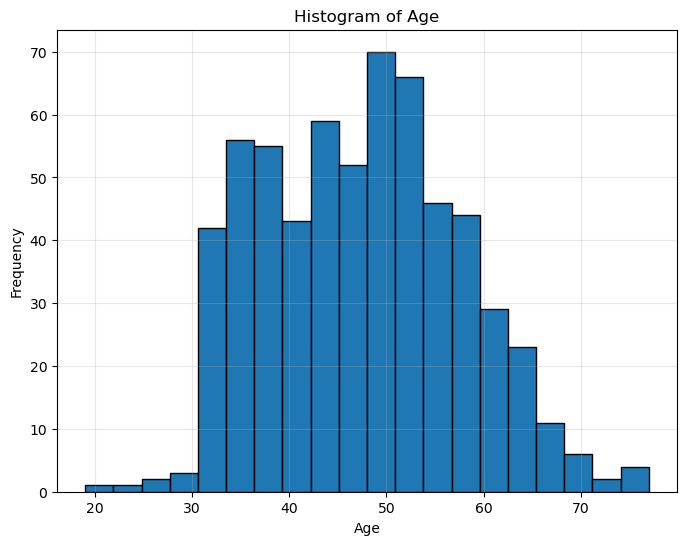

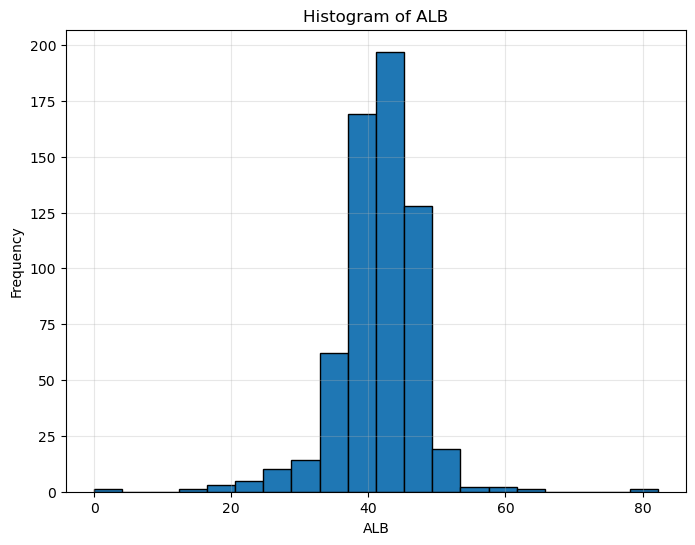

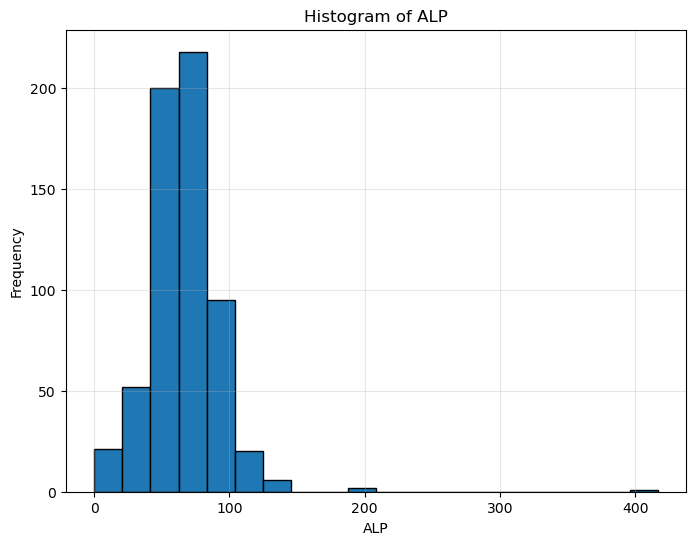

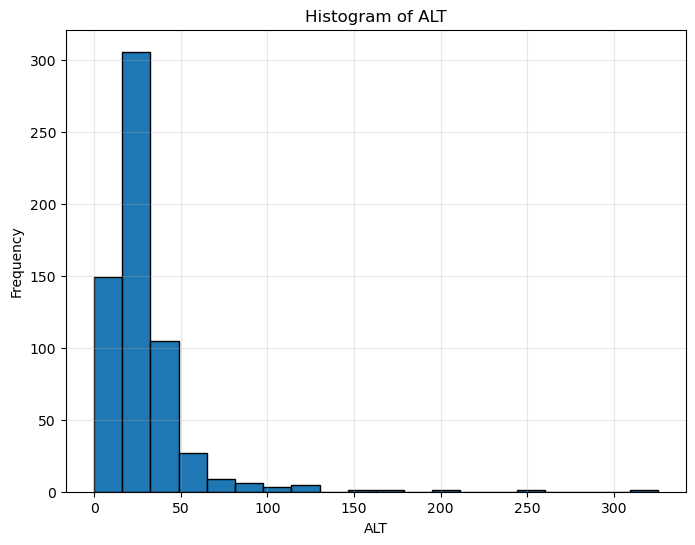

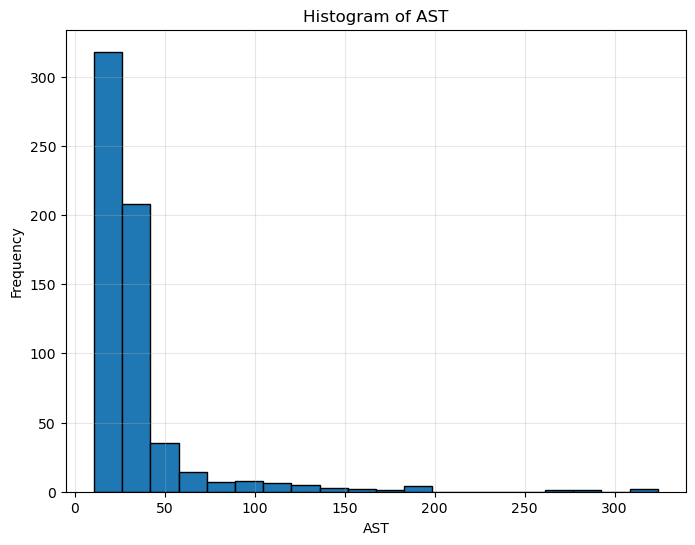

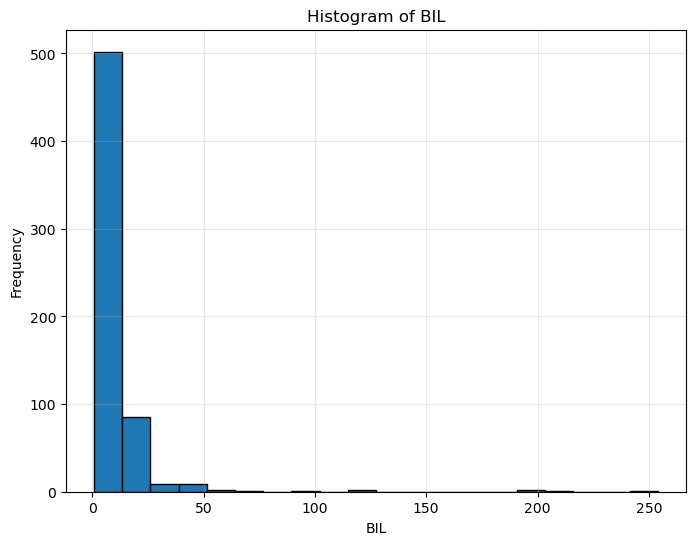

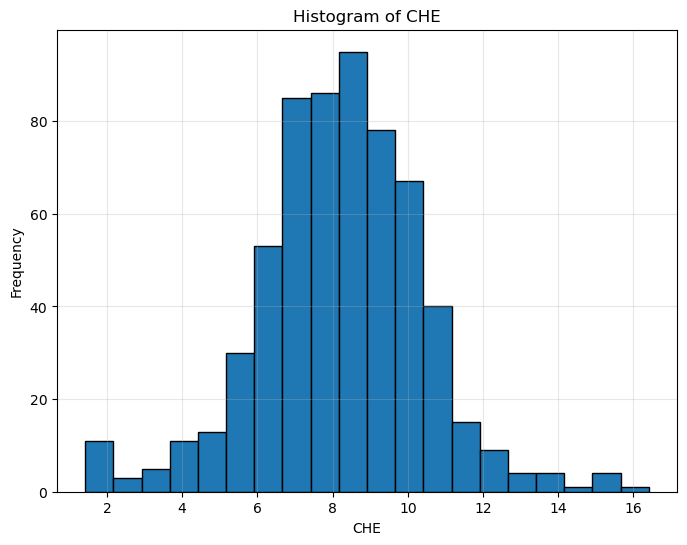

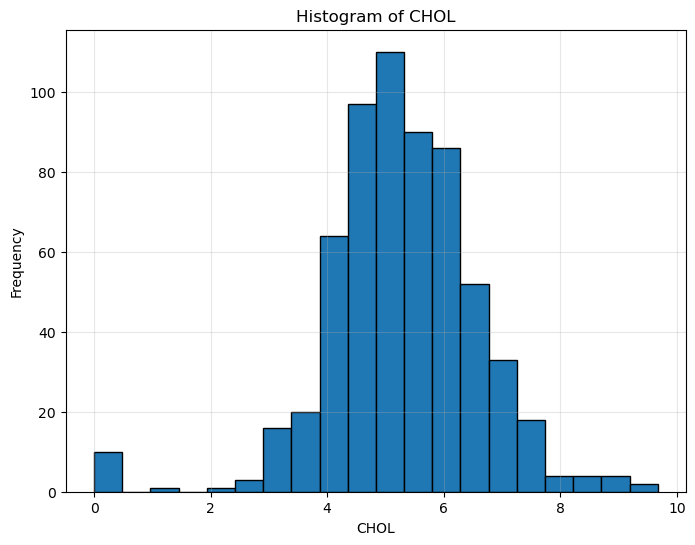

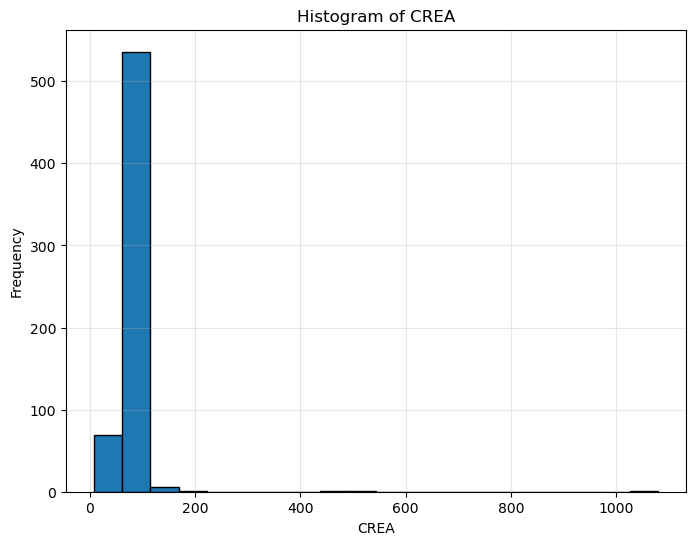

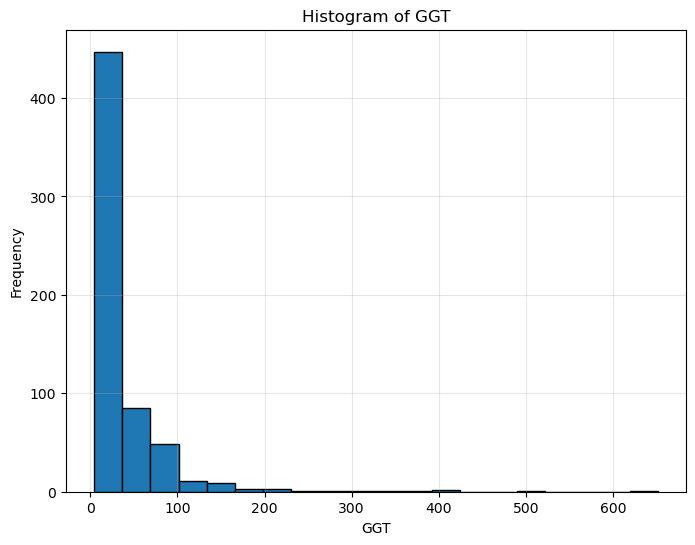

In [506]:
Col = ["Age", 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT']

for column in Col:
    plt.figure(figsize=(8, 6))
    plt.hist(df[column].dropna(), bins=20, edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

<Axes: >

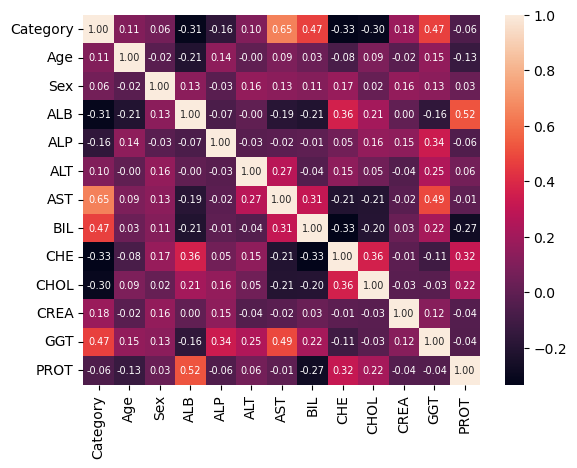

In [508]:
sns.heatmap(df.corr() , annot = True, fmt=".2f",annot_kws={"size": 7}  )

<Axes: ylabel='count'>

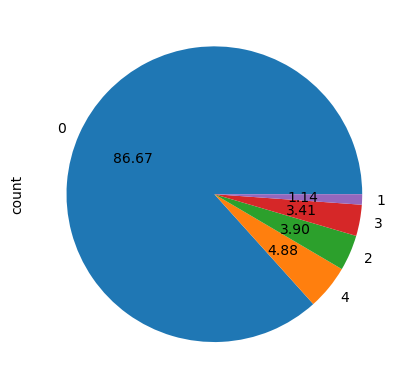

In [510]:
df['Category'].value_counts().plot(kind='pie', autopct='%.2f')

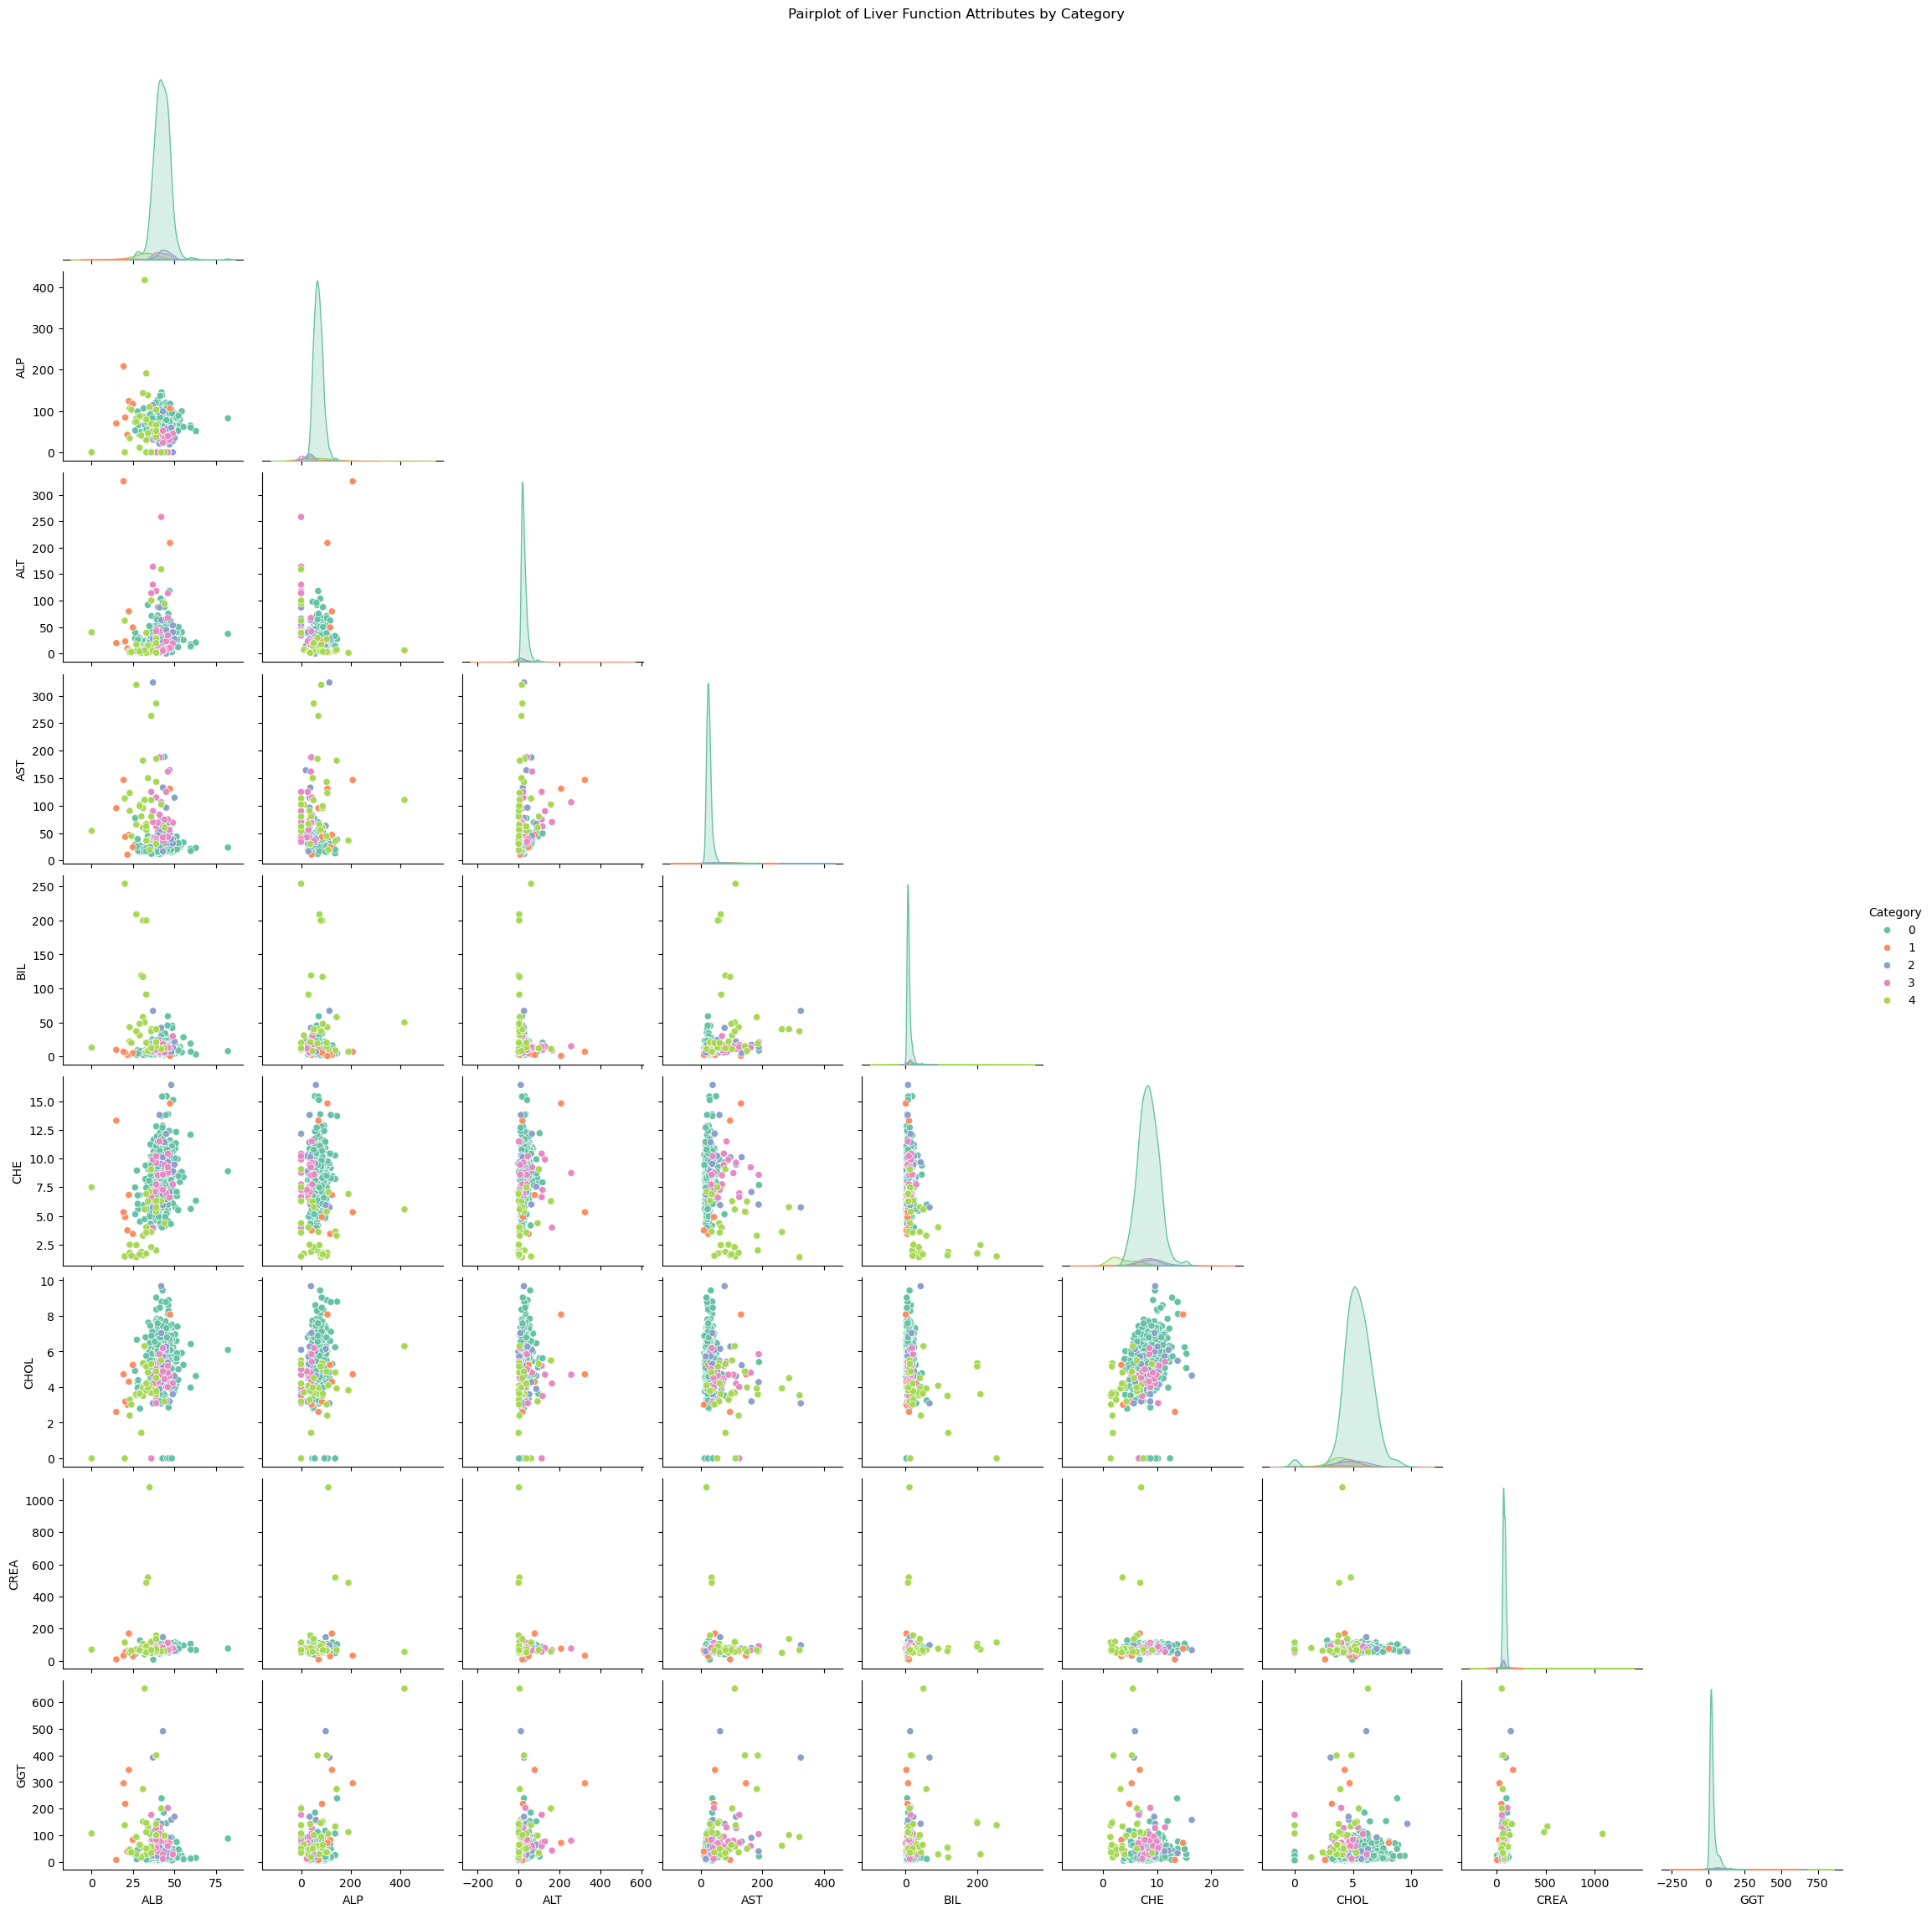

In [512]:
numerical_cols = ['ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT']

# Step 4: Create the pairplot
pair_plot = sns.pairplot(df[numerical_cols + ['Category']], hue='Category', corner=True, diag_kind='kde', palette='Set2')

plt.suptitle('Pairplot of Liver Function Attributes by Category', y=1.02)
pair_plot.savefig("pairplot_output.png")
plt.show()

## Model Building

In [514]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [515]:
kmeans = KMeans(n_clusters=3, random_state=13)
clusters = kmeans.fit_predict(scaled_data)

In [516]:
df['Cluster'] = clusters

# As per Clusters
# 0 Likely Mild hepatitis
# 1 Severe / Critical Group hepatitis
# 2 Healthy or least Affected hepatitis

cluster_mapping = {0: 'Mild', 1: 'Severe', 2: 'Least affected'}
df['Cluster'] = df['Cluster'].map(cluster_mapping)

In [517]:
df.head(5)

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,Cluster
0,0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,Severe
1,0,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,Severe
2,0,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,Severe
3,0,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,Severe
4,0,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,Severe


In [518]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

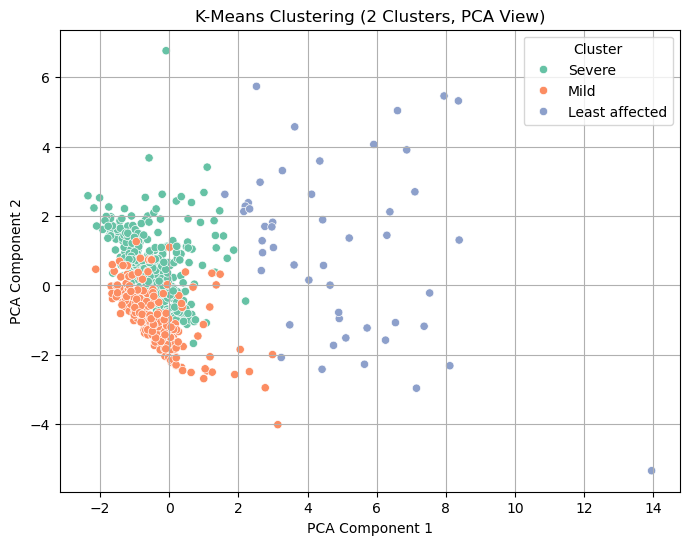

In [525]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('K-Means Clustering (2 Clusters, PCA View)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

In [526]:
# df.to_csv(getcwd + "/clustered.csv", index=False)

In [529]:
columns = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'Category', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT', 'Sex' ]

cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=columns)
centers_df

,Age,ALB,ALP,ALT,AST,BIL,Category,CHE,CHOL,CREA,GGT,PROT,Sex
0,0.100437,47.388646,0.026201,40.582533,65.937555,20.978603,24.216594,6.962009,7.800175,5.290218,69.288210,23.246288,71.209170
1,0.151335,46.590504,1.000000,43.369139,66.725816,30.816617,30.723442,9.922849,8.889347,5.483294,84.600890,35.718694,72.855786
2,3.346939,53.122449,0.693878,33.591837,64.881633,46.520408,112.126531,42.259184,5.285306,3.844286,114.581633,141.883673,68.893878


In [531]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [533]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [535]:
kmeans.inertia_

5959.550100464647

In [537]:
kmeans3_sil_score = silhouette_score(scaled_data, kmeans.labels_)
kmeans3_sil_score

0.17253727863213023

## Limitations

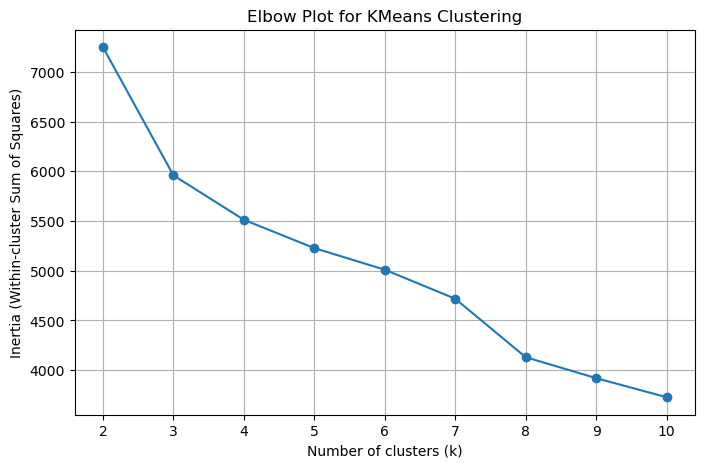

[7248.658584076256, 5960.107409368028, 5512.836132126725, 5228.109315909037, 5010.97803866534, 4718.568760732968, 4131.00489552047, 3920.1084545254826, 3728.2583006185155]


In [540]:
# Elbow plot: k from 2 to 10
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=13)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot for KMeans Clustering')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True)
plt.show()
print(inertia)

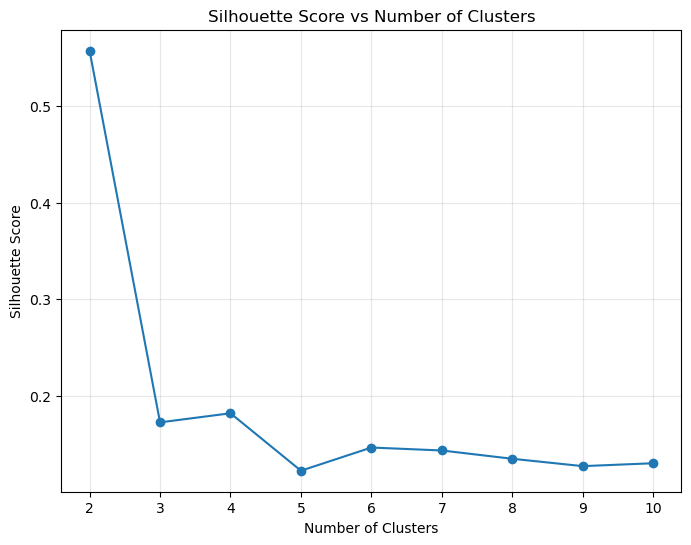

[0.5571207720407731, 0.17253727863213023, 0.18194410036057856, 0.12248963075517505, 0.14649000206294968, 0.1434327511048481, 0.13484867191398797, 0.12723712679542867, 0.13023129100078373]


In [541]:
silhouette_scores = []
k_range = range(2, 11)

for n_clusters in k_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()
print(silhouette_scores)

## After clustering Analysis

In [553]:
df_copy = df.copy()
df_copy.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,Cluster,PCA1,PCA2
0,0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,Severe,0.151805,-1.295681
1,0,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,Severe,-1.147687,0.323027
2,0,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,Severe,-0.903855,1.335046
3,0,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,Severe,-0.380603,0.100739
4,0,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,Severe,-0.222807,-0.176821


/var/folders/48/psb2zmrd3z3fwqqy8md0ym2m0000gn/T/ipykernel_3340/2889320700.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_age_counts = df_copy.groupby(['Cluster', 'age_group']).size().unstack(fill_value=0)


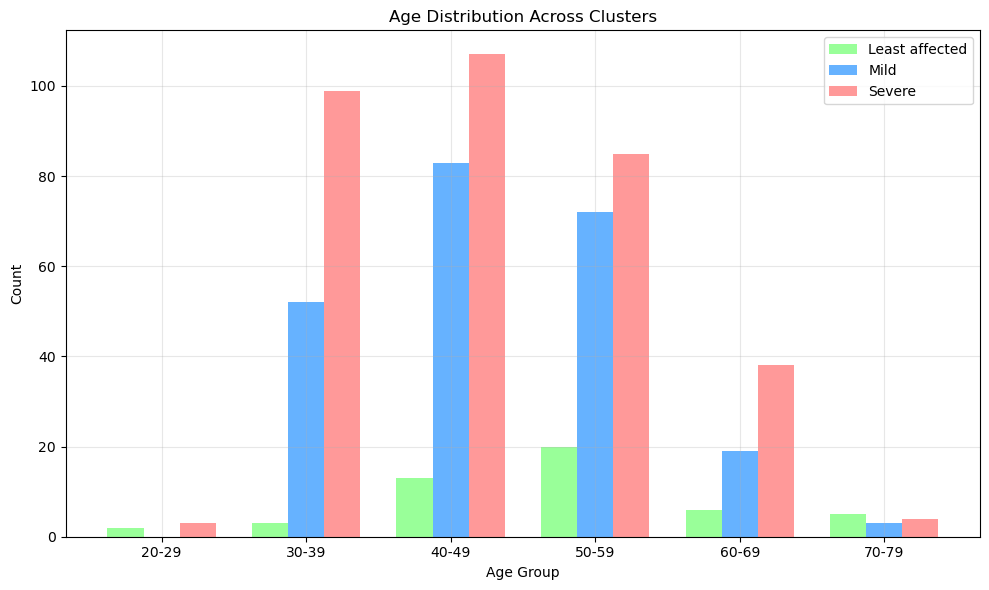

In [555]:
# Define age bins (adjust ranges based on your data, e.g., 20-30, 30-40, etc.)
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']

# Bin the ages
df_copy['age_group'] = pd.cut(df_copy['Age'], bins=age_bins, labels=age_labels, right=False)

# Group by cluster and age group, count occurrences
cluster_age_counts = df_copy.groupby(['Cluster', 'age_group']).size().unstack(fill_value=0)

# Plot a pie chart for each cluster
clusters = cluster_age_counts.index
bar_width = 0.25
index = range(len(age_labels))

plt.figure(figsize=(10, 6))
for i, cluster in enumerate(clusters):
    plt.bar([j + i * bar_width for j in index], cluster_age_counts.loc[cluster], bar_width, label= f'{cluster}', color=['#99FF99', '#66B2FF', '#FF9999'][i % 3])

plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Distribution Across Clusters')
plt.xticks([j + bar_width for j in index], age_labels)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

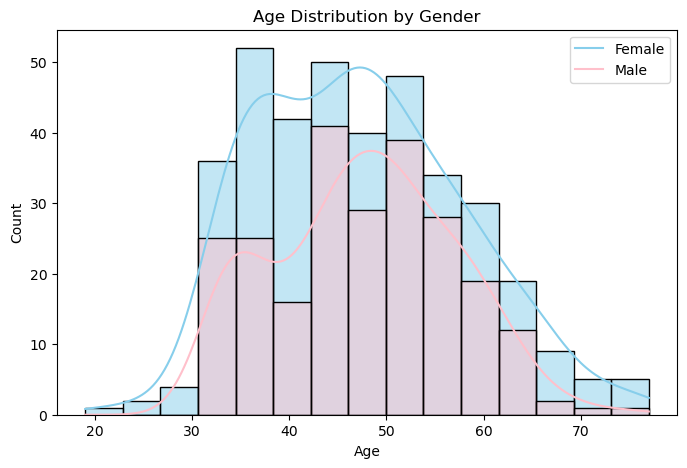

In [559]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Sex', kde=True, bins=15, palette={0: "pink", 1: "skyblue"})
plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(labels=["Female", "Male"])
plt.show()

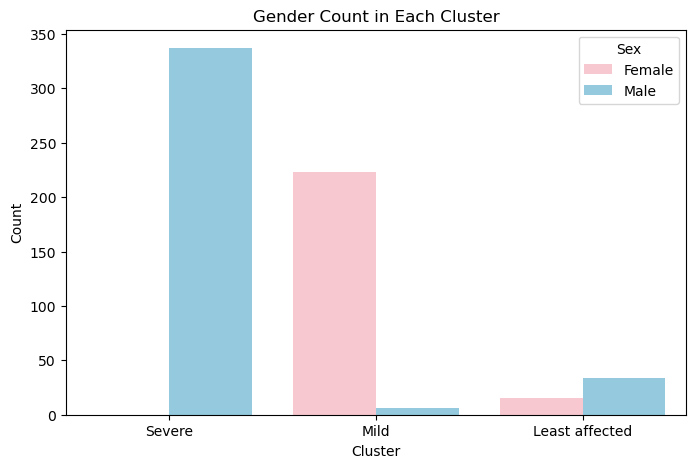

In [550]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Cluster', hue='Sex', palette={0: "pink", 1: "skyblue"})
plt.title("Gender Count in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Sex", labels=["Female", "Male"])
plt.show()

/var/folders/48/psb2zmrd3z3fwqqy8md0ym2m0000gn/T/ipykernel_3340/2661917885.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severe_counts = df_male[df_male['Cluster'] == 'Severe'].groupby('age_group').size().reindex(age_labels, fill_value=0)
/var/folders/48/psb2zmrd3z3fwqqy8md0ym2m0000gn/T/ipykernel_3340/2661917885.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mild_counts = df_male[df_male['Cluster'] == 'Mild'].groupby('age_group').size().reindex(age_labels, fill_value=0)
/var/folders/48/psb2zmrd3z3fwqqy8md0ym2m0000gn/T/ipykernel_3340/2661917885.py:15: FutureWarning: The default of observed=False i

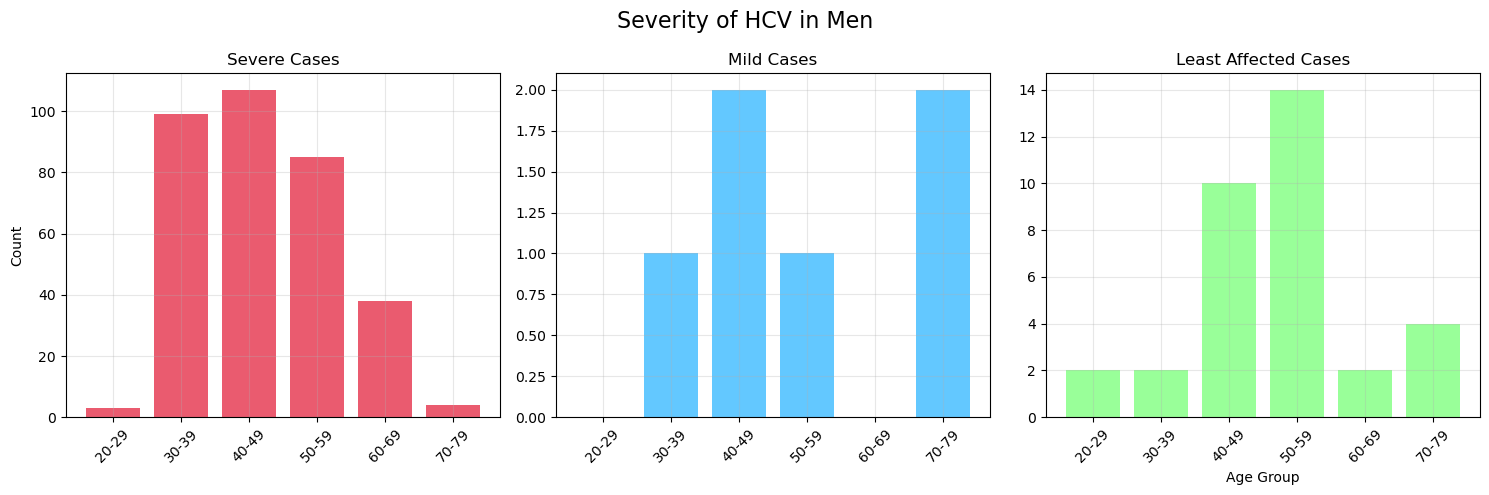

In [613]:
df_male = df[df['Sex'] == 1].dropna(subset=['Age'])

# Convert Age to numeric, coercing errors to NaN and drop any remaining invalid rows
df_male['Age'] = pd.to_numeric(df_male['Age'], errors='coerce')
df_male = df_male.dropna(subset=['Age'])

# Bin the ages
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df_male['age_group'] = pd.cut(df_male['Age'], bins=age_bins, labels=age_labels, right=False)

# Group by age_group and count each cluster, reindex to include all age groups
severe_counts = df_male[df_male['Cluster'] == 'Severe'].groupby('age_group').size().reindex(age_labels, fill_value=0)
mild_counts = df_male[df_male['Cluster'] == 'Mild'].groupby('age_group').size().reindex(age_labels, fill_value=0)
least_counts = df_male[df_male['Cluster'] == 'Least affected'].groupby('age_group').size().reindex(age_labels, fill_value=0)

# Create side-by-side subplots with shared x-axis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# Plot Severe cluster
ax1.bar(age_labels, severe_counts, color='#EA5B6F')
ax1.set_ylabel('Count')
ax1.set_title('Severe Cases')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot Mild cluster
ax2.bar(age_labels, mild_counts, color='#63C8FF')
ax2.set_title('Mild Cases')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot Least affected cluster
ax3.bar(age_labels, least_counts, color='#99FF99')
ax3.set_xlabel('Age Group')
ax3.set_title('Least Affected Cases')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

fig.suptitle('Severity of HCV in Men', fontsize=16)
# Adjust layout
plt.tight_layout()
plt.show()

/var/folders/48/psb2zmrd3z3fwqqy8md0ym2m0000gn/T/ipykernel_3340/2384662239.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severe_counts = df_female[df_female['Cluster'] == 'Mild'].groupby('age_group').size().reindex(age_labels, fill_value=0)
/var/folders/48/psb2zmrd3z3fwqqy8md0ym2m0000gn/T/ipykernel_3340/2384662239.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  least_counts = df_female[df_female['Cluster'] == 'Least affected'].groupby('age_group').size().reindex(age_labels, fill_value=0)


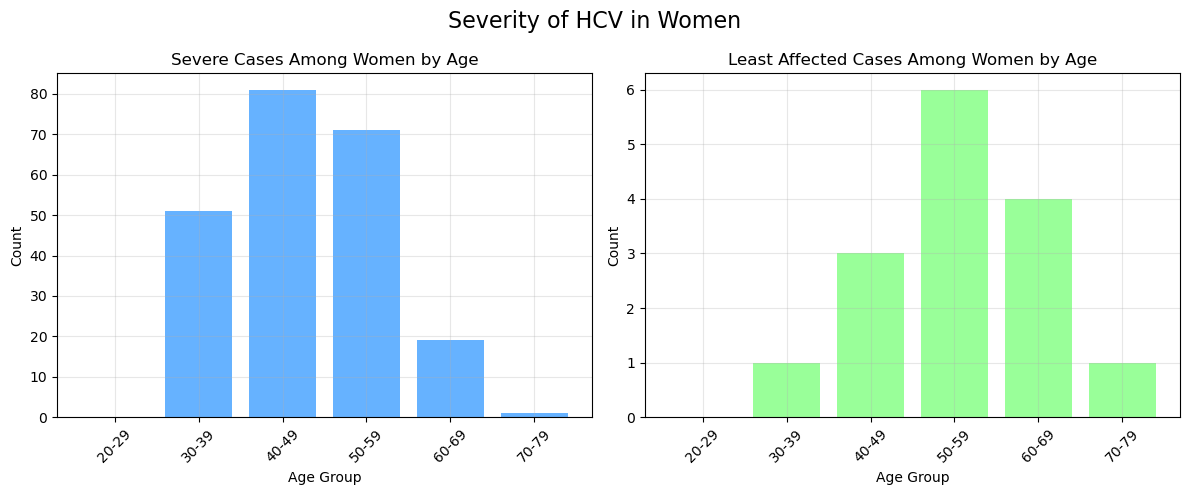

In [623]:
df_male = df[df['Sex'] == 0].dropna(subset=['Age'])

df_female['Age'] = pd.to_numeric(df_female['Age'], errors='coerce')
df_female = df_female.dropna(subset=['Age'])

# Bin the ages
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df_female['age_group'] = pd.cut(df_female['Age'], bins=age_bins, labels=age_labels, right=False)

# Group by age_group and count Severe and Least affected clusters, reindex to include all age groups
severe_counts = df_female[df_female['Cluster'] == 'Mild'].groupby('age_group').size().reindex(age_labels, fill_value=0)
least_counts = df_female[df_female['Cluster'] == 'Least affected'].groupby('age_group').size().reindex(age_labels, fill_value=0)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Severe cluster
ax1.bar(age_labels, severe_counts, color='#66B2FF')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Count')
ax1.set_title('Severe Cases Among Women by Age')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot Least affected cluster
ax2.bar(age_labels, least_counts, color='#99FF99')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Count')
ax2.set_title('Least Affected Cases Among Women by Age')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

fig.suptitle('Severity of HCV in Women', fontsize=16)
# Adjust layout
plt.tight_layout()
plt.show()